# 📊 Loan Risk Model Performance & Accuracy Evaluation

This notebook evaluates and compares the performance of all **5 trained credit risk models**:
1. 🌲 **Random Forest Classifier** (`loan_risk_model_random_forest.pkl`)
2. ⚡ **XGBoost Classifier** (`loan_risk_model_xgboost.pkl`)
3. 🚀 **LightGBM Classifier** (`loan_risk_model_lightgbm.pkl`)
4. 📈 **Logistic Regression Classifier** (`loan_risk_model_logistic_regression.pkl`)
5. 🛡️ **Gradient Boosting Classifier** (`loan_risk_model_gradient_boosting.pkl`)

### Evaluation Metrics:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **ROC AUC**
- **Confusion Matrix**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sklearn.compose._column_transformer as _c
from sklearn.impute import SimpleImputer

# Patch for scikit-learn version compatibility during unpickling
if not hasattr(_c, '_RemainderColsList'):
    class _RemainderColsList(list):
        pass
    _c._RemainderColsList = _RemainderColsList

def patch_model_imputers(obj):
    if hasattr(obj, '__dict__'):
        if isinstance(obj, SimpleImputer):
            if getattr(obj, 'strategy', '') in ['most_frequent', 'constant']:
                obj._fill_dtype = object
            else:
                obj._fill_dtype = float
        for k, v in list(obj.__dict__.items()):
            patch_model_imputers(v)
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            patch_model_imputers(item)
    elif isinstance(obj, dict):
        for k, v in obj.items():
            patch_model_imputers(v)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from IPython.display import display

# Setup paths
base_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'
dataset_path = os.path.join(base_dir, 'Dataset_XGBoost.csv')
if not os.path.exists(dataset_path):
    dataset_path = os.path.join(base_dir, 'Dataset.csv')

model_files = {
    'Random Forest': 'loan_risk_model_random_forest.pkl',
    'XGBoost': 'loan_risk_model_xgboost.pkl',
    'LightGBM': 'loan_risk_model_lightgbm.pkl',
    'Logistic Regression': 'loan_risk_model_logistic_regression.pkl',
    'Gradient Boosting': 'loan_risk_model_gradient_boosting.pkl'
}

print(f"Using Dataset: {os.path.abspath(dataset_path)}")
for name, file in model_files.items():
    print(f"Using {name}: {os.path.abspath(os.path.join(base_dir, file))}")

Using Dataset: d:\Research\Loan Risk\notebook\Dataset_XGBoost.csv
Using Random Forest: d:\Research\Loan Risk\notebook\loan_risk_model_random_forest.pkl
Using XGBoost: d:\Research\Loan Risk\notebook\loan_risk_model_xgboost.pkl
Using LightGBM: d:\Research\Loan Risk\notebook\loan_risk_model_lightgbm.pkl
Using Logistic Regression: d:\Research\Loan Risk\notebook\loan_risk_model_logistic_regression.pkl
Using Gradient Boosting: d:\Research\Loan Risk\notebook\loan_risk_model_gradient_boosting.pkl


In [2]:
# 2. Load dataset and models with compatibility patch
print("Loading Dataset...")
df = pd.read_csv(dataset_path)

loaded_models = {}
print("Loading models...")
for name, filename in model_files.items():
    path = os.path.join(base_dir, filename)
    if os.path.exists(path):
        m = joblib.load(path)
        patch_model_imputers(m)
        loaded_models[name] = m
        print(f"✅ Successfully loaded: {name}")
    else:
        print(f"⚠️ Missing model file: {filename}")

Loading Dataset...
Loading models...
✅ Successfully loaded: Random Forest
✅ Successfully loaded: XGBoost
✅ Successfully loaded: LightGBM
✅ Successfully loaded: Logistic Regression
✅ Successfully loaded: Gradient Boosting


In [3]:
# 3. Prepare Features & Train-Test Split (80:20)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (36000, 18)
Test set shape: (9000, 18)


In [4]:
# 4. Evaluate All 5 Models
results = {}
confusion_matrices = {}

for name, model in loaded_models.items():
    # Preprocess & Predict
    X_transformed = model.named_steps['preprocessor'].transform(X_test)
    y_pred = model.named_steps['classifier'].predict(X_transformed)
    
    if hasattr(model.named_steps['classifier'], 'predict_proba'):
        y_prob = model.named_steps['classifier'].predict_proba(X_transformed)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    elif hasattr(model.named_steps['classifier'], 'decision_function'):
        y_prob = model.named_steps['classifier'].decision_function(X_transformed)
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan
        
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': auc
    }
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

print("All 5 models evaluated successfully!")

All 5 models evaluated successfully!


In [5]:
# 5. Display Model Comparison Table
comparison_df = pd.DataFrame(results).T
comparison_df_formatted = comparison_df.copy()

for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    comparison_df_formatted[col] = comparison_df_formatted[col].apply(lambda x: f"{x*100:.2f}%")
comparison_df_formatted['ROC AUC'] = comparison_df_formatted['ROC AUC'].apply(lambda x: f"{x:.4f}")

print("="*55)
print("              5-MODEL COMPARISON TABLE")
print("="*55)
display(comparison_df_formatted)

              5-MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,100.00%,100.00%,100.00%,100.00%,1.0000
XGBoost,96.93%,96.36%,89.65%,92.89%,0.9957
LightGBM,94.56%,92.27%,82.54%,87.13%,0.9869
Logistic Regression,89.39%,77.35%,74.23%,75.76%,0.9529
Gradient Boosting,92.46%,88.27%,76.37%,81.89%,0.9727


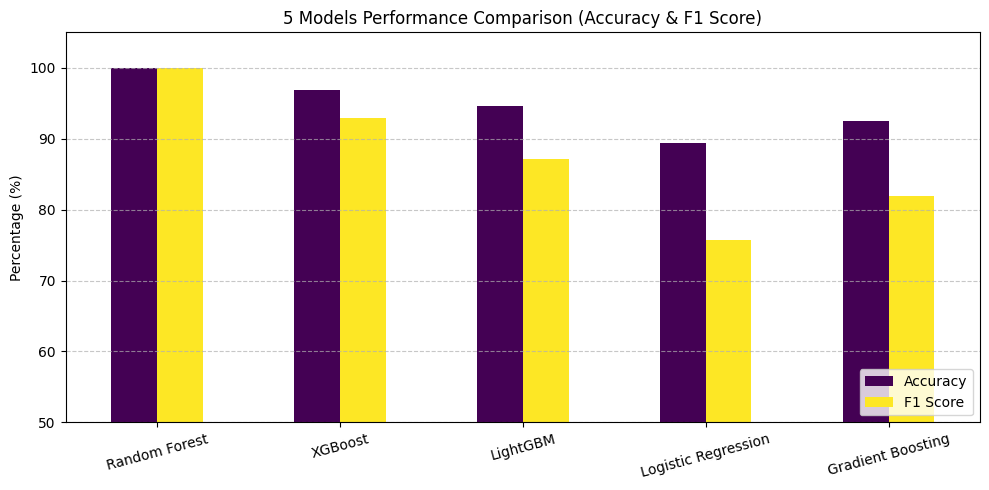

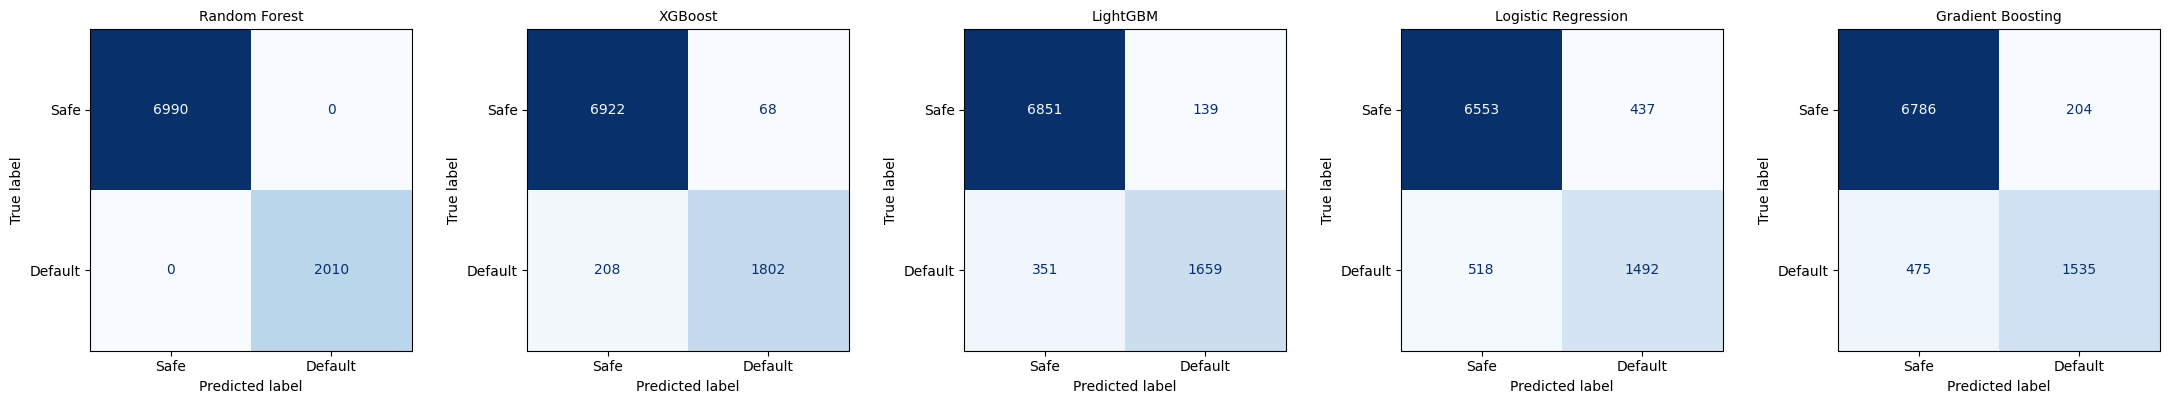

In [6]:
# 6. Plot Performance Bar Charts & Confusion Matrices
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = comparison_df[['Accuracy', 'F1 Score']] * 100
metrics_to_plot.plot(kind='bar', ax=ax, colormap='viridis')
plt.title('5 Models Performance Comparison (Accuracy & F1 Score)')
plt.ylabel('Percentage (%)')
plt.ylim(50, 105)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Plot Confusion Matrices for all 5 models
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for idx, (name, cm) in enumerate(confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Default'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=10)
plt.tight_layout()
plt.show()